In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
nltk.download('punkt')         
nltk.download('stopwords')     
nltk.download('wordnet')       
nltk.download('omw-1.4')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
from collections import Counter

[nltk_data] Downloading package punkt to /Users/nicosanse/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nicosanse/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/nicosanse/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/nicosanse/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [38]:
dialogues = pd.read_csv("Harry_Potter_Movies/Dialogue.csv", encoding='latin-1')
full_saga_df = dialogues.drop(columns=['Dialogue ID', 'Place ID', 'Patronus', 'Wand (Wood)', 'Wand (Core)'], errors='ignore')

In [39]:
text = " ".join(full_saga_df["Dialogue"].dropna().astype(str).values)

# tokenizzazione
tokens = word_tokenize(text)


most_common_20 = Counter(tokens).most_common(20)
for word, count in most_common_20:
    print(f"{word}: {count}")

.: 8336
,: 4951
I: 2528
you: 2514
!: 2441
?: 2428
the: 2062
to: 1895
's: 1738
it: 1260
a: 1173
n't: 1123
of: 1060
...: 977
that: 786
is: 743
Harry: 704
me: 685
You: 676
do: 669


In [40]:
# minuscolo
tokens = [word.lower() for word in tokens]


most_common_20 = Counter(tokens).most_common(20)
for word, count in most_common_20:
    print(f"{word}: {count}")

.: 8336
,: 4951
you: 3194
i: 2529
!: 2441
?: 2428
the: 2395
to: 1925
it: 1786
's: 1740
a: 1260
n't: 1123
of: 1097
that: 1030
...: 977
and: 938
do: 876
is: 812
he: 741
we: 730


In [41]:
# rimozione stopwords
stop_words = set(stopwords.words('english'))
tokens = [word for word in tokens if word not in stop_words]



most_common_20 = Counter(tokens).most_common(20)
for word, count in most_common_20:
    print(f"{word}: {count}")

.: 8336
,: 4951
!: 2441
?: 2428
's: 1740
n't: 1123
...: 977
harry: 709
're: 393
know: 385
well: 371
'll: 363
one: 341
--: 341
've: 307
potter: 307
'm: 293
think: 291
go: 284
come: 280


In [42]:
# lemmatizzazione
lemmatizer = WordNetLemmatizer()
tokens = [lemmatizer.lemmatize(word) for word in tokens]


most_common_20 = Counter(tokens).most_common(20)
for word, count in most_common_20:
    print(f"{word}: {count}")

.: 8336
,: 4951
!: 2441
?: 2428
's: 1740
n't: 1123
...: 977
harry: 709
know: 417
're: 393
well: 371
'll: 363
one: 348
--: 341
potter: 310
've: 307
think: 302
come: 299
go: 297
'm: 293


In [43]:
# rimozione punteggiatura
punctuation = string.punctuation 
tokens = [word for word in tokens if word not in punctuation]



most_common_20 = Counter(tokens).most_common(20)
for word, count in most_common_20:
    print(f"{word}: {count}")

's: 1740
n't: 1123
...: 977
harry: 709
know: 417
're: 393
well: 371
'll: 363
one: 348
--: 341
potter: 310
've: 307
think: 302
come: 299
go: 297
'm: 293
see: 252
would: 251
right: 235
like: 234


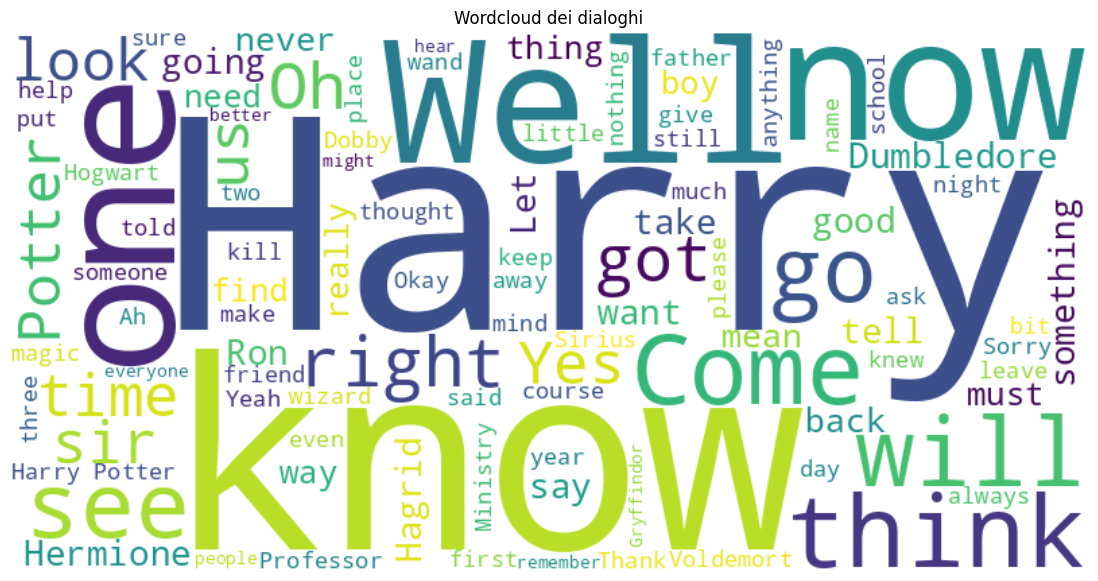

In [44]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'  # puoi provare anche 'plasma', 'inferno', ecc.
).generate(text)


plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Wordcloud dei dialoghi")
plt.show()

#fig = plt.figure(figsize=(20,14))
#wordcloud = WordCloud(width=1600, height=800, background_color="black").generate_from_frequencies(Counter(flat_list))
#plt.axis("off")
#plt.imshow(wordcloud, interpolation='antialiased')

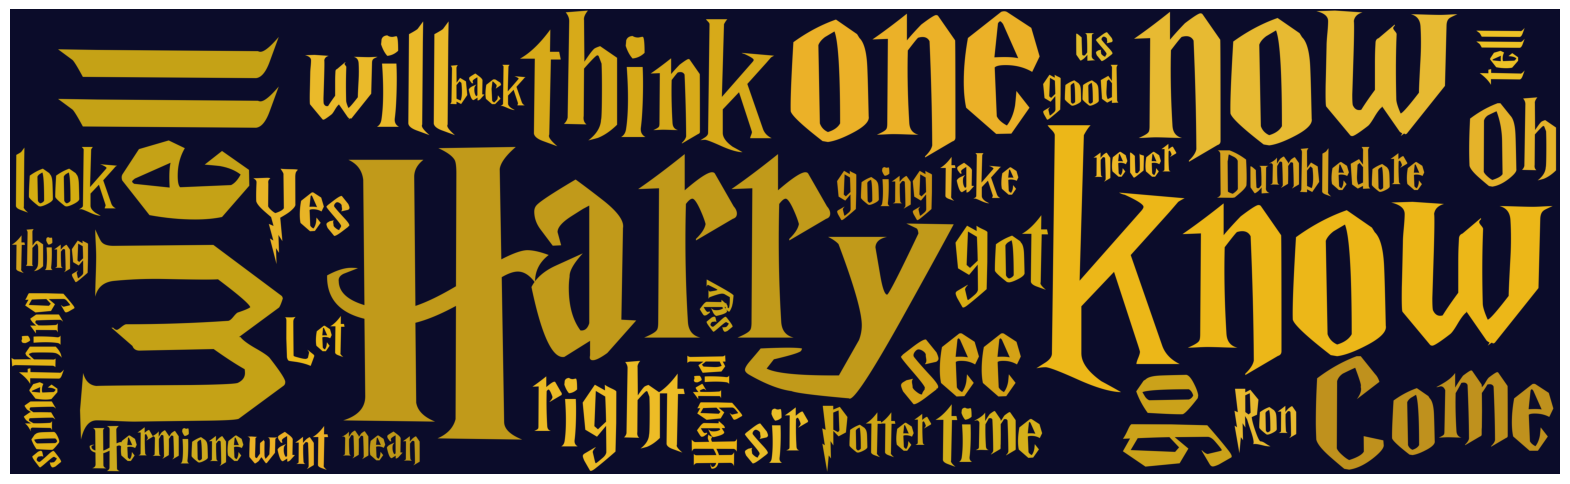

In [45]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random


def color_func(*args, **kwargs):
    return "#CFB53B"

def recolor(*args, **kwargs):
    hue = random.randint(42, 48)           # tonalità oro/giallo scuro
    saturation = random.randint(74, 86)    # saturazione alta ma non troppo piena
    lightness = random.randint(42, 55)     # luminosità più bassa per oro scuro
    return f"hsl({hue}, {saturation}%, {lightness}%)"

# Crea la WordCloud
wc = WordCloud(
    width=1000,
    height=300,
    background_color='#0B0C2A',        
    color_func=color_func,         
    font_path='Harry P Font/HARRYP__.TTF',  
    contour_color="black",
    max_words=35,
    contour_width=100,
    prefer_horizontal=0.9,                         
    scale=5,                                       
    random_state=21
)

# Genera la nuvola
wc.generate(text)
wc.recolor(color_func=recolor)

# Visualizza
plt.figure(figsize=(20, 16))
plt.imshow(wc, interpolation='antialiased')
plt.axis('off')
plt.show()
